In [1]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# Load the dataset
df = pd.read_csv('plant_disease_dataset.csv')

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(10000, 5)


In [4]:
df['disease_present'].unique()

array([1, 0], dtype=int64)

In [5]:
print("Dataset info : ")
df.info()
print("\nDataset Head : ")
print(df.head())
print("\n Checking Null Values :")
print(df.isna().sum())

Dataset info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      10000 non-null  float64
 1   humidity         10000 non-null  float64
 2   rainfall         10000 non-null  float64
 3   soil_pH          10000 non-null  float64
 4   disease_present  10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB

Dataset Head : 
   temperature   humidity   rainfall   soil_pH  disease_present
0    27.483571  33.215053   0.572758  4.975875                1
1    24.308678  36.945005  42.522346  8.165266                0
2    28.238443  34.026189  16.095303  6.316734                1
3    32.615149  41.104180  20.311015  6.164949                0
4    23.829233  51.971785  11.851323  8.482468                0

 Checking Null Values :
temperature        0
humidity           0
rainfall           0
soil_pH       

C:\Users\HP\AppData\Local\Temp\ipykernel_3084\1598437208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'disease_present',data = df, palette = 'Set2')


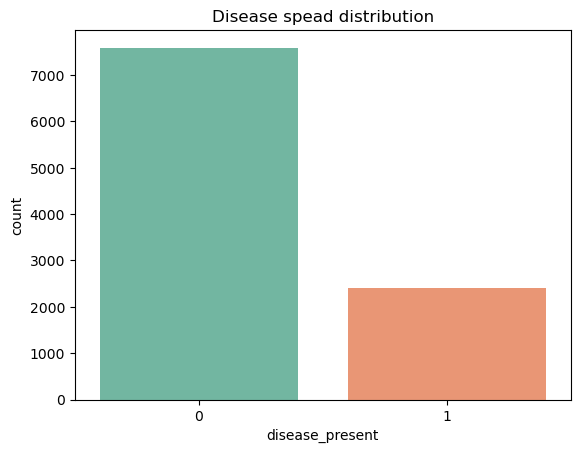

In [6]:
# Disease Spread Distribution
sns.countplot(x = 'disease_present',data = df, palette = 'Set2')
plt.title("Disease spead distribution")
plt.show()

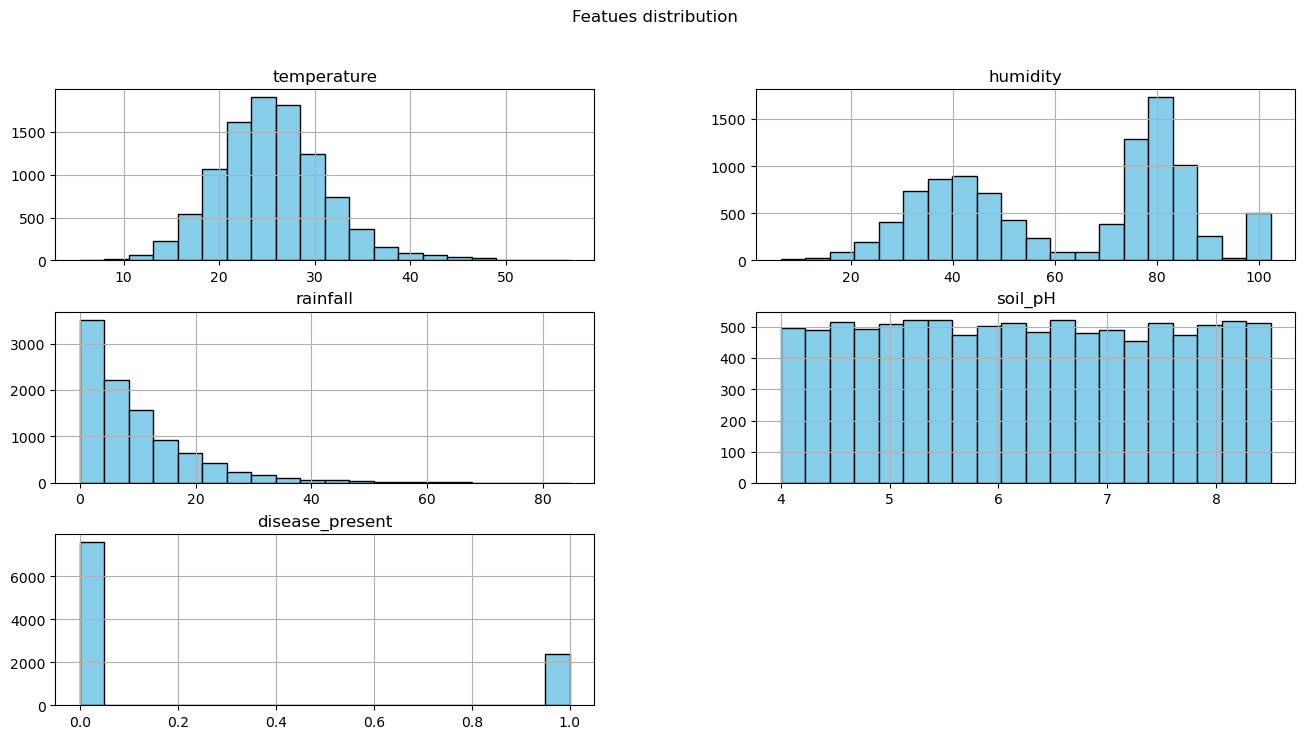

In [7]:
df.hist(bins = 20,figsize = (16,8),color ='skyblue',edgecolor='black')
plt.suptitle("Featues distribution")
plt.show()

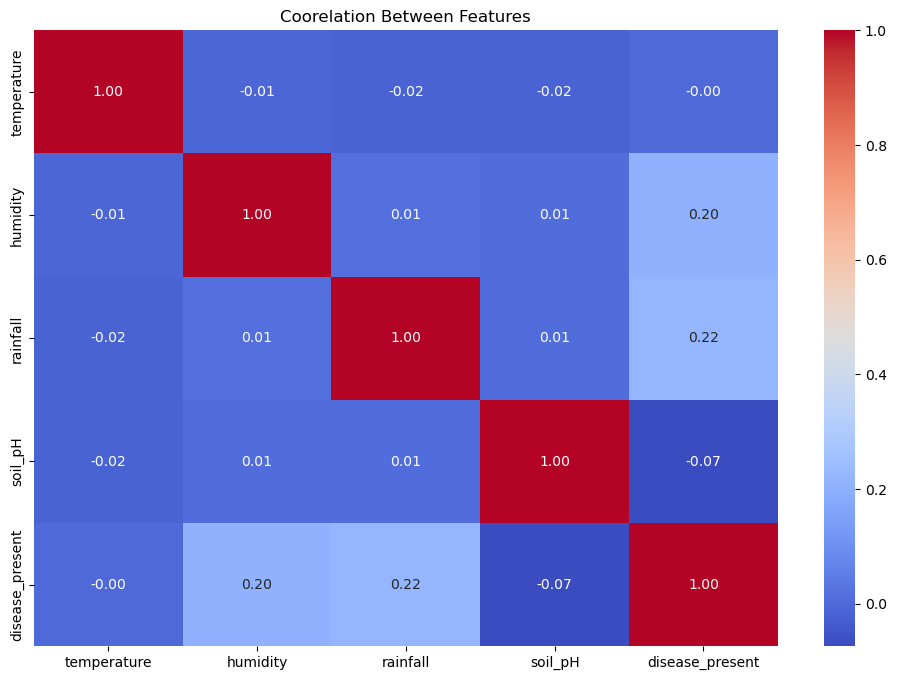

In [8]:
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(),annot= True,cmap ='coolwarm',fmt='.2f')
plt.title("Coorelation Between Features")
plt.show()

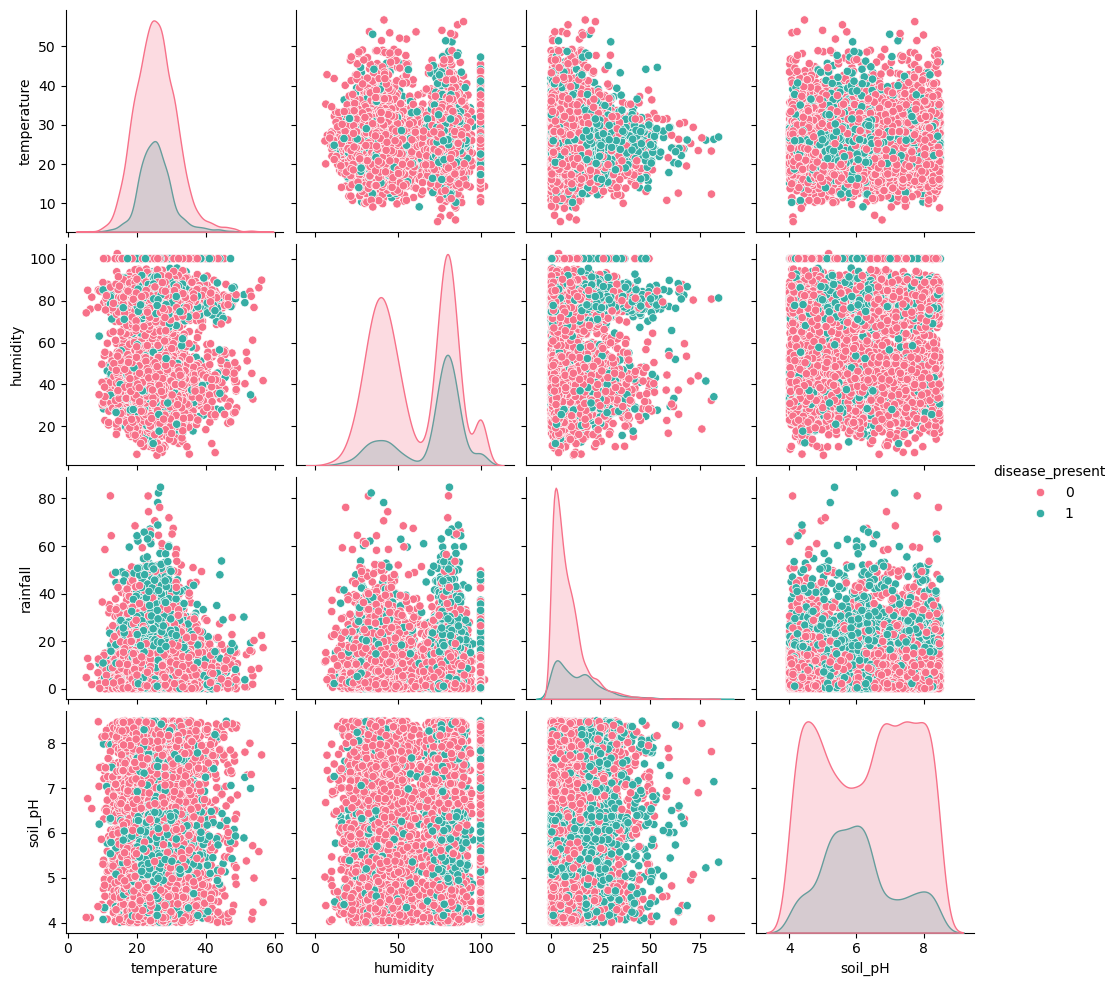

In [9]:
import warnings
warnings.filterwarnings('ignore')
sns.pairplot(df,hue = 'disease_present',diag_kind ='kde',palette = 'husl')
plt.show()

In [10]:
df.skew()

temperature        0.616484
humidity          -0.175760
rainfall           2.049917
soil_pH            0.018036
disease_present    1.211338
dtype: float64

In [11]:
X = df.drop('disease_present', axis=1)
y = df['disease_present']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state =5)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
models = {
    "DecisionTree : ": DecisionTreeClassifier(),
    "RandomForest : ": RandomForestClassifier(),
    "XGBoost : ": XGBClassifier(use_label_encoder = False,
eval_metric = 'logloss',random_state = 5),
    "LightGBM : ": LGBMClassifier(random_state = 5)
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled,y_train)

    y_train_pred =model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_accuracy = accuracy_score(y_train,y_train_pred) 
    test_accuracy = accuracy_score(y_test,y_test_pred)
    train_cm = confusion_matrix(y_train_pred,y_train)
    test_cm = confusion_matrix(y_test,y_test_pred)


    print(list(models.keys())[i])

    print("Model Performancr for training Set")

    print("Accuracy :", train_accuracy)
    print("cm :", train_cm)

    print("-------------------------------------------------------------")

    print(list(models.keys())[i])

    print("Model performance for test set")
    print("Accuracy :", test_accuracy)
    print("cm :", test_cm)



DecisionTree : 
Model Performancr for training Set
Accuracy : 1.0
cm : [[5657    0]
 [   0 1843]]
-------------------------------------------------------------
DecisionTree : 
Model performance for test set
Accuracy : 0.7836
cm : [[1634  299]
 [ 242  325]]
RandomForest : 
Model Performancr for training Set
Accuracy : 0.9997333333333334
cm : [[5657    2]
 [   0 1841]]
-------------------------------------------------------------
RandomForest : 
Model performance for test set
Accuracy : 0.8632
cm : [[1825  108]
 [ 234  333]]
XGBoost : 
Model Performancr for training Set
Accuracy : 0.9357333333333333
cm : [[5541  366]
 [ 116 1477]]
-------------------------------------------------------------
XGBoost : 
Model performance for test set
Accuracy : 0.8532
cm : [[1802  131]
 [ 236  331]]
[LightGBM] [Info] Number of positive: 1843, number of negative: 5657
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_col_wise=true` to

In [14]:
# Model Comparison

model_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Test Accuracy': [0.7804, 0.8632, 0.8532, 0.8664]
})

model_results = model_results.sort_values(
    by='Test Accuracy',
    ascending=False
).reset_index(drop=True)

print("Model Performance Comparison:")
print(model_results)

best_model = model_results.iloc[0]

print("\nBest Model:")
print(best_model['Model'])
print("Accuracy:", best_model['Test Accuracy'])

Model Performance Comparison:
           Model  Test Accuracy
0       LightGBM         0.8664
1  Random Forest         0.8632
2        XGBoost         0.8532
3  Decision Tree         0.7804

Best Model:
LightGBM
Accuracy: 0.8664


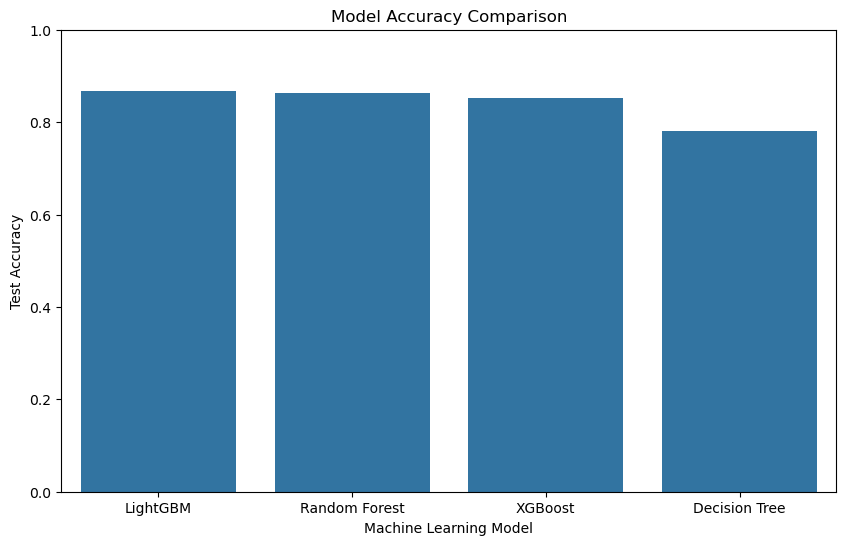

In [15]:
# Visualize Model Performance

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=model_results
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

plt.show()

In [16]:
from sklearn.metrics import classification_report

# Train the best model
best_lgbm = LGBMClassifier(random_state=5, verbose=-1)
best_lgbm.fit(X_train_scaled, y_train)

# Make predictions
y_pred = best_lgbm.predict(X_test_scaled)

# Detailed evaluation
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred))

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1933
           1       0.76      0.60      0.67       567

    accuracy                           0.87      2500
   macro avg       0.82      0.77      0.79      2500
weighted avg       0.86      0.87      0.86      2500



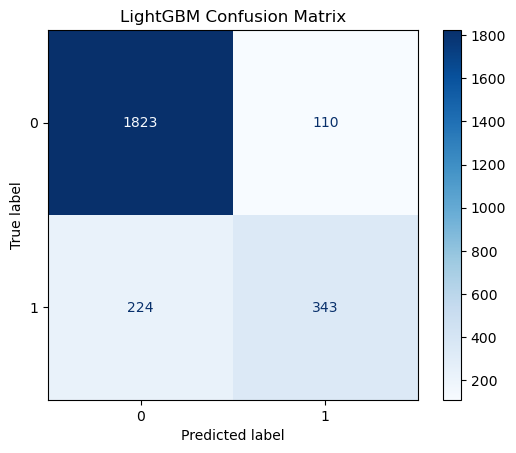

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("LightGBM Confusion Matrix")
plt.show()

       Feature  Importance
3      soil_pH         810
0  temperature         803
2     rainfall         713
1     humidity         674


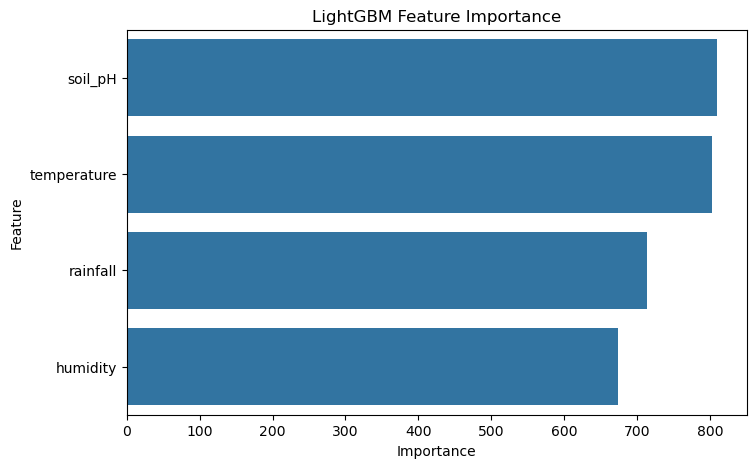

In [18]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

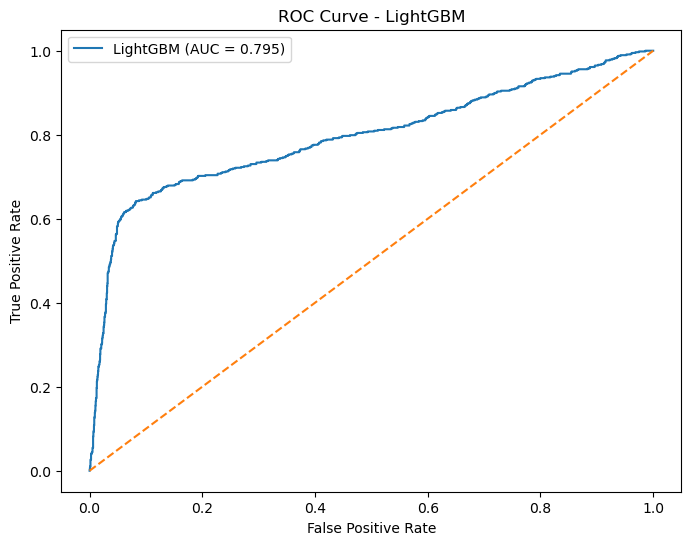

ROC-AUC Score: 0.795


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_prob = best_lgbm.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

## Conclusion and Key Findings

This project developed a machine learning model for predicting the presence of plant disease using environmental factors including temperature, humidity, rainfall, and soil pH.

### Key Findings

- Four machine learning models were evaluated: Decision Tree, Random Forest, XGBoost, and LightGBM.
- LightGBM achieved the highest test accuracy of approximately 86.64%.
- The ROC-AUC score of the LightGBM model was approximately 0.795, indicating a reasonable ability to distinguish between plants with and without disease.
- Soil pH was the most important predictor, followed closely by temperature.
- Rainfall and humidity also contributed to disease prediction.
- The model performed better at identifying disease-absent cases than disease-present cases.
- Recall for the disease-present class was approximately 60%, indicating that further improvement is needed to reduce missed disease cases.

### Practical Recommendations

- Soil pH and temperature should be closely monitored because they were the most influential variables in the model.
- Environmental monitoring systems can incorporate rainfall and humidity measurements alongside soil pH and temperature to support early disease-risk assessment.
- Future model development should focus on improving recall for diseased plants, since failing to identify an infected plant may have significant agricultural consequences.
- Additional features such as plant species, leaf symptoms, soil moisture, geographic location, and seasonal information could potentially improve predictive performance.

### Final Result

LightGBM was selected as the best-performing model in this analysis, with a test accuracy of 86.64% and ROC-AUC score of 0.795.